# Potential Problems in Linear Regression

Exploring common problems that may arise when fitting a linear regression model and using generative AI to create examples that illustrate these issues.

## Issue 1: Non-linearity of the response-predictor relationships

**Discussion: Why it matters & how to detect**
Linear regression assumes a normal distribution where the predictors (x) and response (y) produce a straight line (aka linear). This linear relationship is explained by that a one-unit change in X produces a constant change in Y regardless of where you are on X. 

A way to understand the x and y relationship is to investigate the residuals, which is the difference between the actual and predicted values. Residual plots are a graphical tool for understanding linearity where x = fitted values and y = residuals. If the trend on the residual plot is a *not* a smooth fit, there are non-linear associations in the data which is incompatable for linear regression. This is a strict assumption because raw data, especially enviornmental data, typically does not have this linear relationship and thus unsuitable for this statitcial test. 

**Question**
 If you add a polynomial term to fix non-linearity, how do you know what degree to use? And when does it become overfitting?


####  AI Generated Synthetic Data
Using a generative AI tool (such as ChatGPT, Claude, or Claude code) to write Python code that:**(1)** generates synthetic data that clearly illustrates the issue, **(2)** produces plots making the issue visually clear, and **(3)** where applicable, produces additional plots showing how the issue can be addressed.

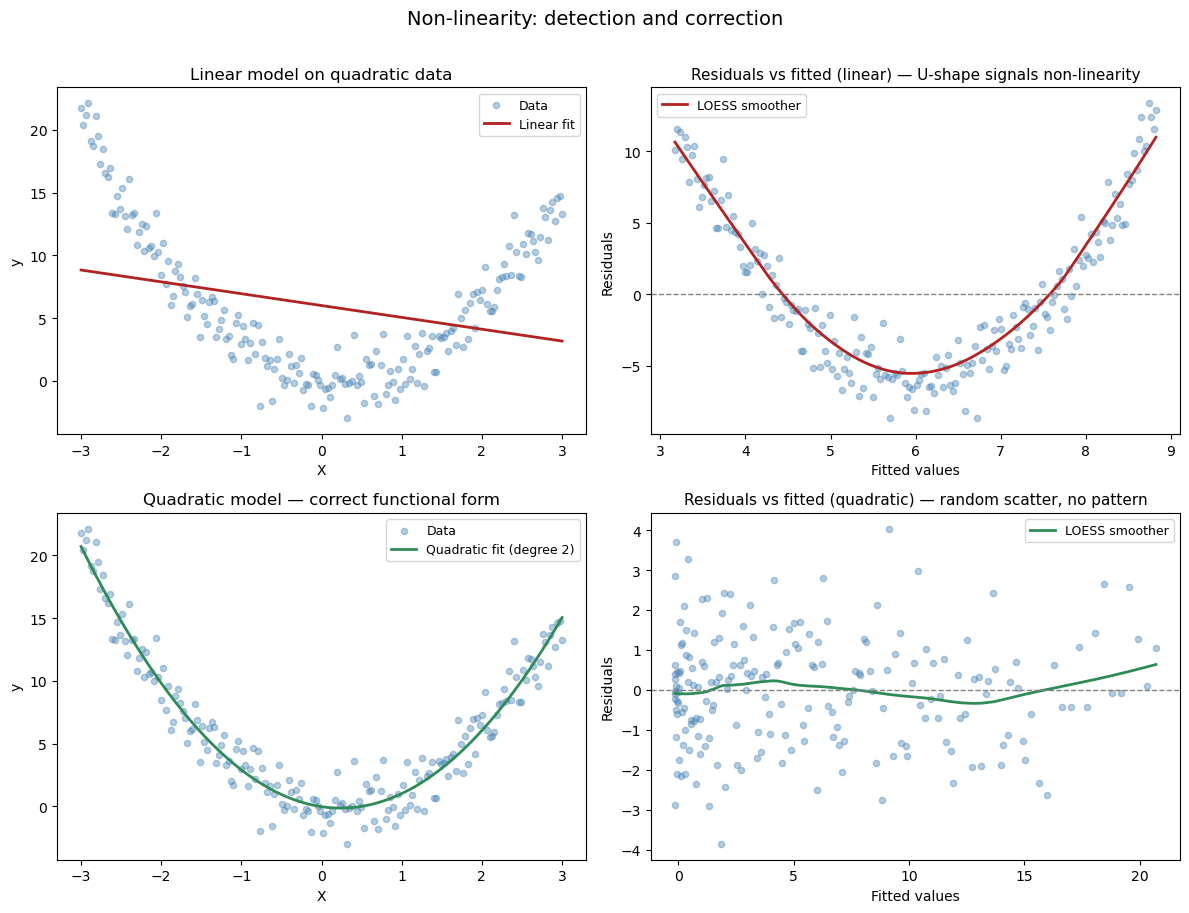

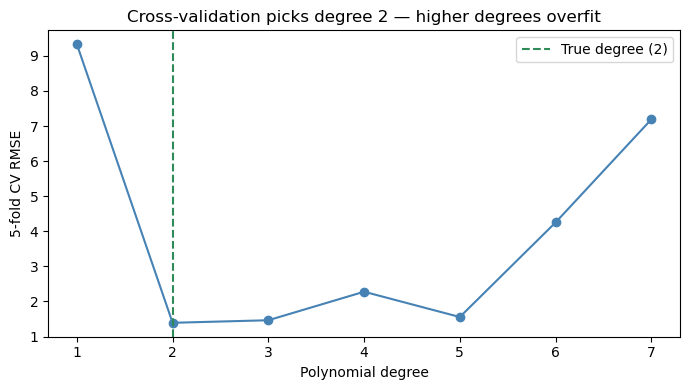

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

np.random.seed(42)

# --- Synthetic data: true relationship is quadratic ---
n = 200
X = np.linspace(-3, 3, n)
y = 2 * X**2 - X + np.random.normal(0, 1.5, n)

X_2d = X.reshape(-1, 1)

# Fit linear model
lin = LinearRegression().fit(X_2d, y)
y_lin = lin.predict(X_2d)
resid_lin = y - y_lin

# Fit quadratic model (degree-2 polynomial)
quad = make_pipeline(PolynomialFeatures(2), LinearRegression())
quad.fit(X_2d, y)
y_quad = quad.predict(X_2d)
resid_quad = y - y_quad

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Non-linearity: detection and correction", fontsize=14, y=1.01)

# --- Plot 1: Raw data + linear fit ---
ax = axes[0, 0]
ax.scatter(X, y, alpha=0.4, s=20, color="steelblue", label="Data")
ax.plot(X, y_lin, color="firebrick", linewidth=2, label="Linear fit")
ax.set_title("Linear model on quadratic data", fontsize=12)
ax.set_xlabel("X"); ax.set_ylabel("y")
ax.legend(fontsize=9)

# --- Plot 2: Residuals vs fitted — LINEAR model ---
ax = axes[0, 1]
smooth = lowess(resid_lin, y_lin, frac=0.4)
ax.scatter(y_lin, resid_lin, alpha=0.4, s=20, color="steelblue")
ax.plot(smooth[:, 0], smooth[:, 1], color="firebrick", linewidth=2, label="LOESS smoother")
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_title("Residuals vs fitted (linear) — U-shape signals non-linearity", fontsize=11)
ax.set_xlabel("Fitted values"); ax.set_ylabel("Residuals")
ax.legend(fontsize=9)

# --- Plot 3: Raw data + quadratic fit ---
ax = axes[1, 0]
X_sort = np.sort(X)
y_quad_sort = quad.predict(X_sort.reshape(-1, 1))
ax.scatter(X, y, alpha=0.4, s=20, color="steelblue", label="Data")
ax.plot(X_sort, y_quad_sort, color="seagreen", linewidth=2, label="Quadratic fit (degree 2)")
ax.set_title("Quadratic model — correct functional form", fontsize=12)
ax.set_xlabel("X"); ax.set_ylabel("y")
ax.legend(fontsize=9)

# --- Plot 4: Residuals vs fitted — QUADRATIC model ---
ax = axes[1, 1]
smooth_q = lowess(resid_quad, y_quad, frac=0.4)
ax.scatter(y_quad, resid_quad, alpha=0.4, s=20, color="steelblue")
ax.plot(smooth_q[:, 0], smooth_q[:, 1], color="seagreen", linewidth=2, label="LOESS smoother")
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_title("Residuals vs fitted (quadratic) — random scatter, no pattern", fontsize=11)
ax.set_xlabel("Fitted values"); ax.set_ylabel("Residuals")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("nonlinearity.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Bonus: CV to choose polynomial degree ---
from sklearn.model_selection import cross_val_score

degrees = range(1, 8)
cv_rmse = []
for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    scores = cross_val_score(model, X_2d, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_rmse.append(-scores.mean())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(degrees), cv_rmse, marker="o", color="steelblue")
ax.axvline(2, color="seagreen", linestyle="--", label="True degree (2)")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("5-fold CV RMSE")
ax.set_title("Cross-validation picks degree 2 — higher degrees overfit", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig("cv_degree.png", dpi=150, bbox_inches="tight")
plt.show()

The top row of graphs show raw data with non linear fits.
-  Top left shows a graph that has an incorrect linear fit ontop of the nonlinear data. 
-  Top right shows a graph with a clear U-shaped residual plot. 

The bottom row of graphs show the fix.
-  Bottom left shows the same U-shaped residual plot with the correct degree 2 polynomal fit. 
-  Bottom right shows a random scatter with the LOESS line hovering around 0.

The final plot shows a 5-fold CV RMSE across polynomal degree 1 through 7. At degree-2, the RMSE bottoms out representing the accurate degree to use. After the 2, the line rises again illustrating the overfitting. 

## Issue 2: Correlation of error terms

**Discussion: Why it matters & how to detect**
Linear regression assumes that all the error terms are *not* correlated. One error term does not infer information about another. If this assumption is violated, the standard error estimates are underestimating the true error terms, making the results overconfident. The predictions and confident intervals appear more narrow, and the p-values appear lower then they should be. Environmental data is typically correlated, weither it's spatially or temporally correlated (aka time series data). Without good experimental design to mitigate correlation risk, we would be overconfidence in our results. To investigate correlation of error terms, plot residuals against time/order and look for runs of same-sign residuals. Additionally, the Durbin-Watson statistic and plotting residuals in the ACF (autocorrelation function) could help detected spikes outside the confidence bands. 

**Question**
Can variables be correlated and their error terms be uncorrelated or vise-versa? Or is it a package deal for correlation in vairables vs error terms? 


####  AI Generated Synthetic Data
Using a generative AI tool (such as ChatGPT, Claude, or Claude code) to write Python code that:**(1)** generates synthetic data that clearly illustrates the issue, **(2)** produces plots making the issue visually clear, and **(3)** where applicable, produces additional plots showing how the issue can be addressed.

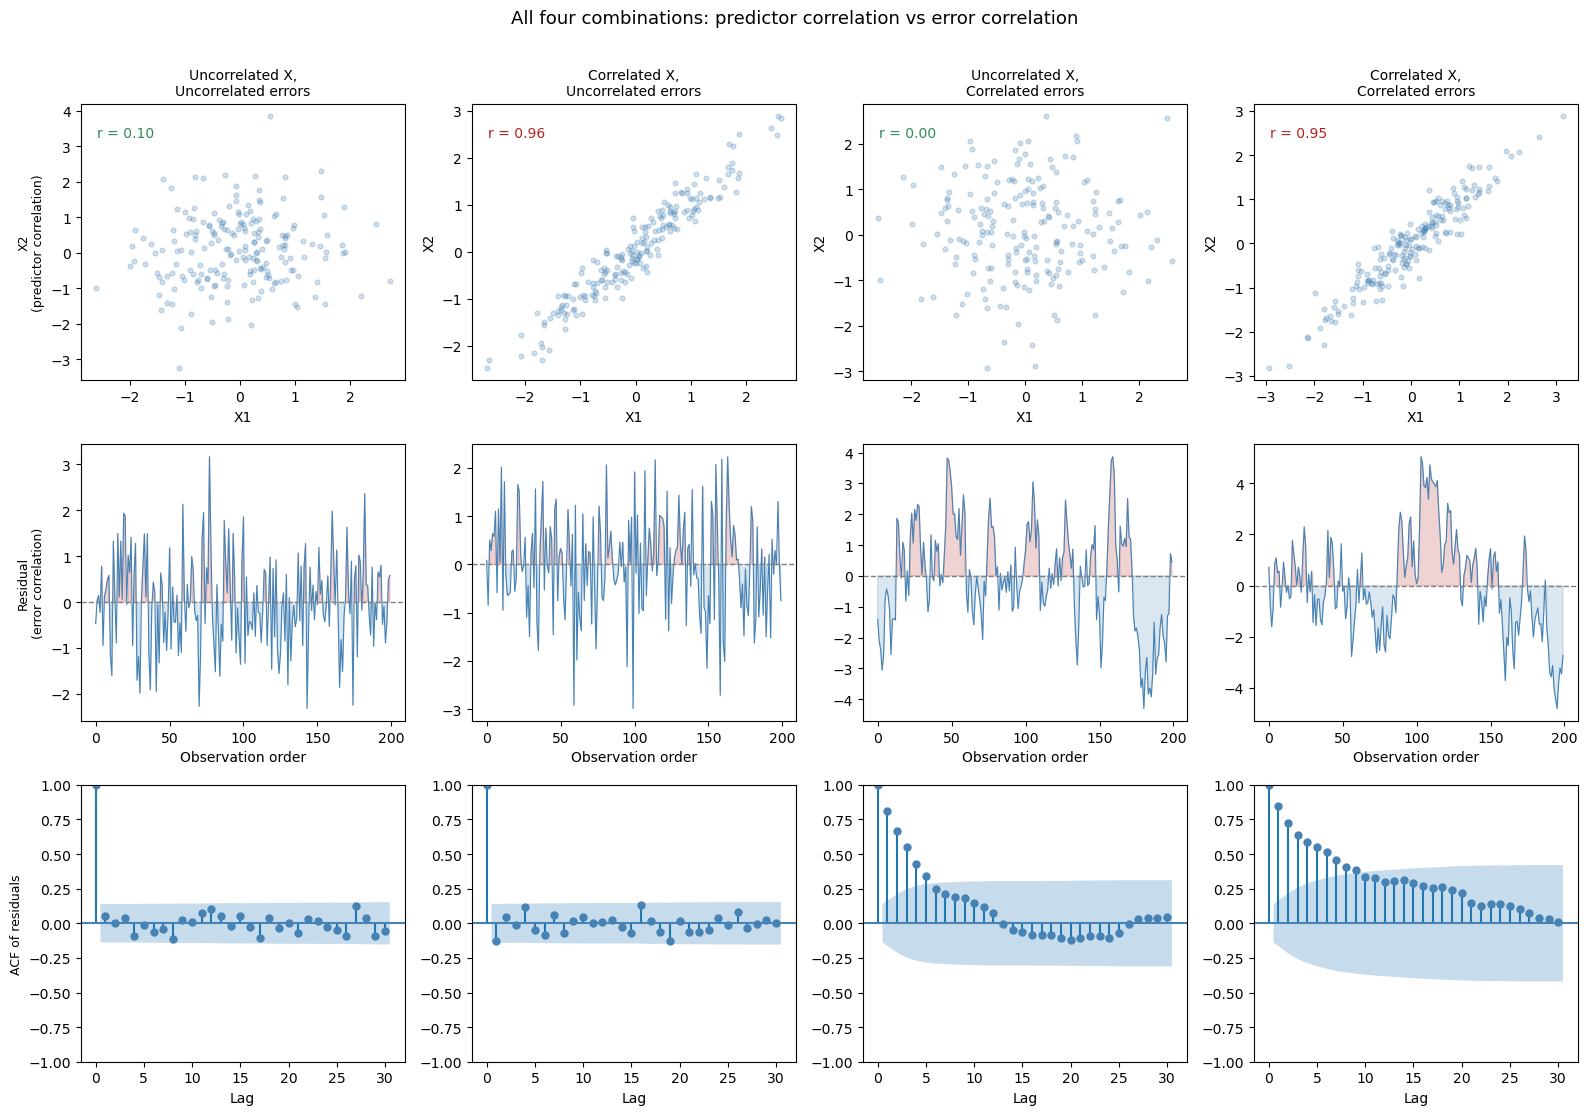

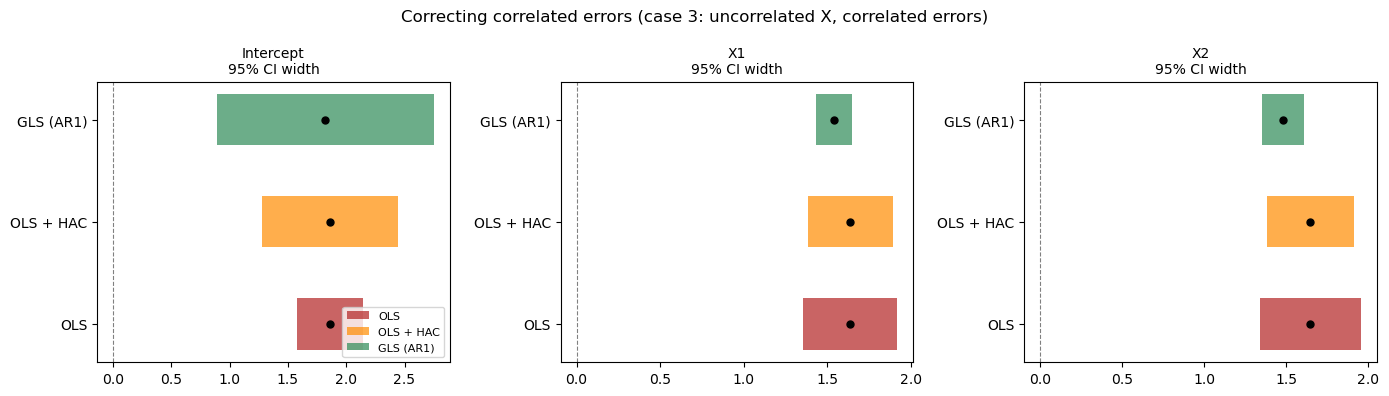

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

np.random.seed(42)
n = 200

def make_errors(autocorrelated, rho=0.85):
    eps = np.zeros(n)
    eps[0] = np.random.normal()
    if autocorrelated:
        for i in range(1, n):
            eps[i] = rho * eps[i-1] + np.random.normal(0, 1)
    else:
        eps = np.random.normal(0, 1, n)
    return eps

def make_predictors(correlated, r=0.95):
    x1 = np.random.normal(0, 1, n)
    if correlated:
        x2 = r * x1 + np.sqrt(1 - r**2) * np.random.normal(0, 1, n)
    else:
        x2 = np.random.normal(0, 1, n)
    return x1, x2

cases = [
    ("Uncorrelated X,\nUncorrelated errors", False, False),
    ("Correlated X,\nUncorrelated errors",   True,  False),
    ("Uncorrelated X,\nCorrelated errors",   False, True),
    ("Correlated X,\nCorrelated errors",     True,  True),
]

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle("All four combinations: predictor correlation vs error correlation", fontsize=13, y=1.01)

for col, (title, corr_x, corr_e) in enumerate(cases):
    x1, x2 = make_predictors(corr_x)
    eps = make_errors(corr_e)
    y = 2 + 1.5 * x1 + 1.5 * x2 + eps

    X = sm.add_constant(np.column_stack([x1, x2]))
    ols = sm.OLS(y, X).fit()
    resid = ols.resid
    r_x = np.corrcoef(x1, x2)[0, 1]

    # --- Row 0: X1 vs X2 scatter ---
    ax = axes[0, col]
    ax.scatter(x1, x2, alpha=0.25, s=12, color="steelblue")
    ax.set_title(title, fontsize=10, fontweight="500")
    ax.set_xlabel("X1"); ax.set_ylabel("X2")
    ax.annotate(f"r = {r_x:.2f}", xy=(0.05, 0.88), xycoords="axes fraction", fontsize=10,
                color="firebrick" if corr_x else "seagreen")
    if col == 0:
        ax.set_ylabel("X2\n(predictor correlation)", fontsize=9)

    # --- Row 1: Residuals over time ---
    ax = axes[1, col]
    ax.plot(resid, linewidth=0.8, color="steelblue")
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.fill_between(range(n), resid, 0,
                    where=(resid > 0), alpha=0.2, color="firebrick")
    ax.fill_between(range(n), resid, 0,
                    where=(resid < 0), alpha=0.2, color="steelblue")
    ax.set_xlabel("Observation order")
    if col == 0:
        ax.set_ylabel("Residual\n(error correlation)", fontsize=9)

    # --- Row 2: ACF of residuals ---
    ax = axes[2, col]
    plot_acf(resid, lags=30, ax=ax, color="steelblue", title="")
    ax.set_xlabel("Lag")
    if col == 0:
        ax.set_ylabel("ACF of residuals", fontsize=9)

plt.tight_layout()
plt.savefig("four_cases.png", dpi=150, bbox_inches="tight")
plt.show()


# --- Correction plot: case 3 (uncorrelated X, correlated errors) ---
from scipy.linalg import toeplitz

x1, x2 = make_predictors(correlated=False)
eps     = make_errors(autocorrelated=True)
y       = 2 + 1.5 * x1 + 1.5 * x2 + eps
X       = sm.add_constant(np.column_stack([x1, x2]))

ols     = sm.OLS(y, X).fit()
hac     = ols.get_robustcov_results(cov_type='HAC', maxlags=5)
rho_hat = np.corrcoef(ols.resid[:-1], ols.resid[1:])[0, 1]
Sigma   = toeplitz(rho_hat ** np.arange(n))
gls     = sm.GLS(y, X, sigma=Sigma).fit()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Correcting correlated errors (case 3: uncorrelated X, correlated errors)", fontsize=12)

labels  = ["Intercept", "X1", "X2"]
methods = [("OLS",        ols,  "firebrick"),
           ("OLS + HAC",  hac,  "darkorange"),
           ("GLS (AR1)",  gls,  "seagreen")]

# CI comparison per coefficient
for i, label in enumerate(labels):
    ax = axes[i]
    for j, (name, model, color) in enumerate(methods):
        ci = model.conf_int()[i]
        coef = model.params[i]
        ax.barh(j, ci[1] - ci[0], left=ci[0], height=0.5, color=color, alpha=0.7, label=name)
        ax.plot(coef, j, "o", color="black", markersize=5, zorder=5)
    ax.set_yticks(range(3)); ax.set_yticklabels([m[0] for m in methods])
    ax.set_title(f"{label}\n95% CI width", fontsize=10)
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
    if i == 0:
        ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("correction.png", dpi=150, bbox_inches="tight")
plt.show()


**Figure 1:**
-  Row 1: Scatter plots showing correlated (tight diagonal) and uncorrelated (cloud) predictors VS  correlated and uncorrelated error values. 
-  Row 2: Resdiuals overtime - when the errors are uncorrelated, the plots show random noise; when the errors are correlated, the plots show same-signs. 
-  Row 3: ACF - spikes outside the bands only in the two correlated-error cases, completely regardless of what the predictors are doing. 

**Figure 2:** Uncorrelated X + correlated errors and shows the 95% CI for each coefficient (Intercept, X1, X2) across OLS, HAC, and GLS. 
In all three graphs, the coefficeinet estimates (the dots) do not move much between the methods, but the confidence intervals change drastically. The correlated error values do not chnage the coefficeinets but can make you overconfident about them. 


## Issue 3: Outliers
**Discussion: Why it matters & how to detect**
An outliear is a value that occurs far outside of the other predicted values. Outliears can skew disutbutions and results in favor of the outlier's position. To identify outliers, we can use (1) residual plots that have fitter values on the x and corresponding residuals on the y and/or (2) plotting studentized residuals which is caculated by dividing the residuals and the standard error. Removing outliers is a solution but must be handled with care as removing predictors can harm the model accuracy. 

**Question**
What exactly is the difference between an outlier, a high-leverage point, and an influential point — and is there one metric that captures all three?


####  AI Generated Synthetic Data
Using a generative AI tool (such as ChatGPT, Claude, or Claude code) to write Python code that:**(1)** generates synthetic data that clearly illustrates the issue, **(2)** produces plots making the issue visually clear, and **(3)** where applicable, produces additional plots showing how the issue can be addressed.

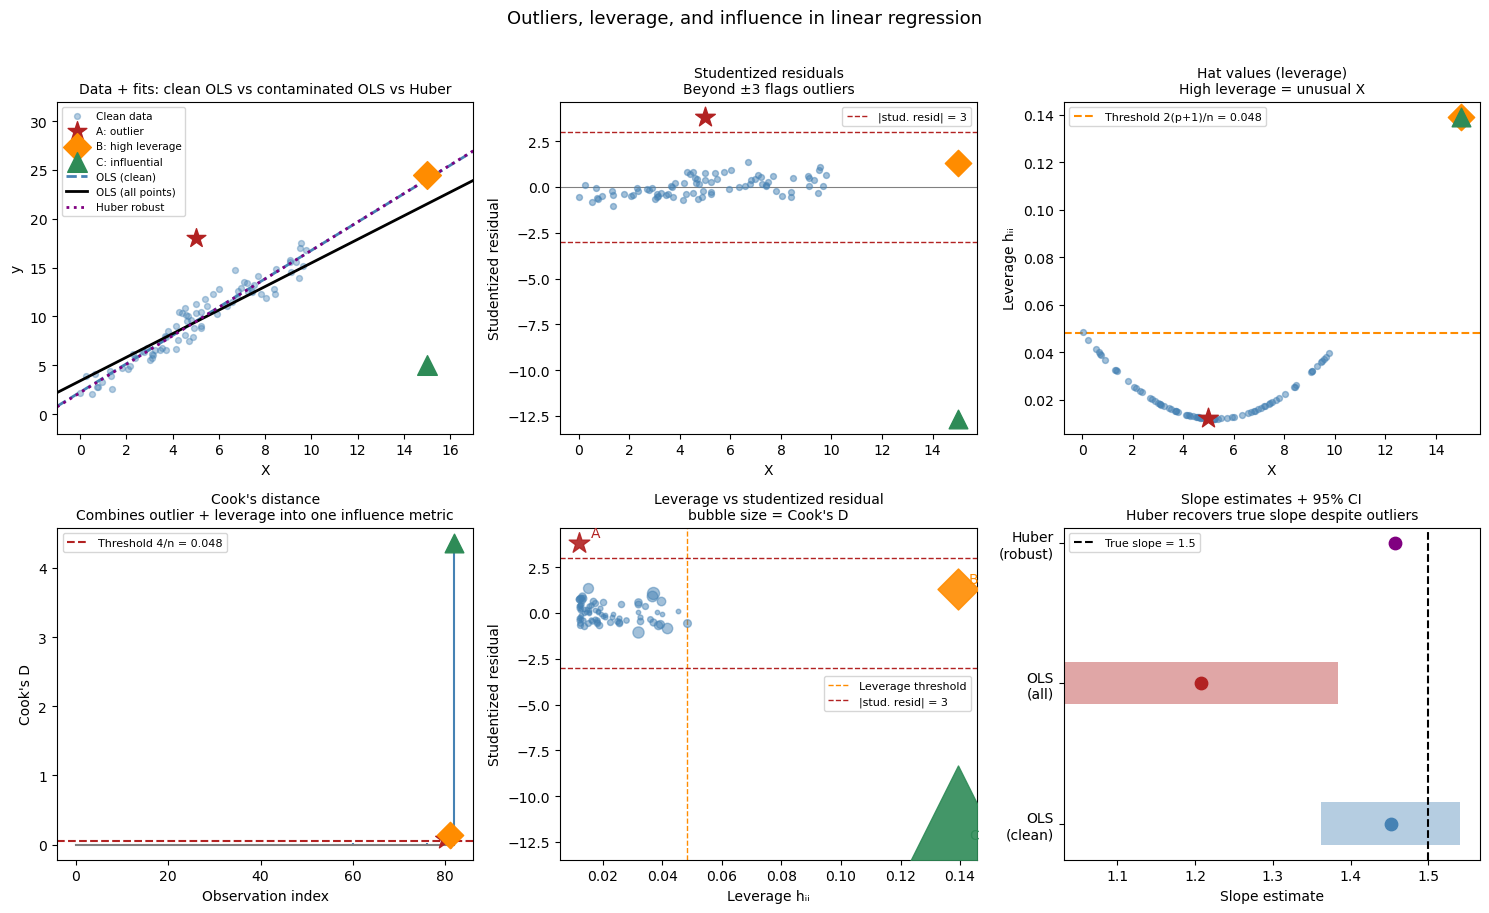

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
from sklearn.linear_model import HuberRegressor

np.random.seed(7)
n = 80

# Clean data
x_clean = np.random.uniform(0, 10, n)
y_clean = 2 + 1.5 * x_clean + np.random.normal(0, 1.2, n)

# Three special points added to clean data:
#   A — outlier only: average X, large residual
#   B — high leverage only: extreme X, sits on the true line
#   C — influential: extreme X AND large residual (worst case)
x_extra = np.array([5.0,  15.0, 15.0])
y_extra = np.array([18.0, 24.5,  5.0])
labels_extra = ["A: outlier", "B: high leverage", "C: influential"]

x_all = np.concatenate([x_clean, x_extra])
y_all = np.concatenate([y_clean, y_extra])

X_all   = sm.add_constant(x_all)
X_clean = sm.add_constant(x_clean)

ols_clean = sm.OLS(y_clean, X_clean).fit()
ols_all   = sm.OLS(y_all,   X_all).fit()

influence = OLSInfluence(ols_all)
student_resid = influence.resid_studentized_external
hat_values    = influence.hat_matrix_diag
cooks_d       = influence.cooks_distance[0]

n_all = len(x_all)
lev_threshold  = 2 * 2 / n_all       # 2(p+1)/n, p=1
cooks_threshold = 4 / n_all

# Robust fit
huber = HuberRegressor().fit(x_all.reshape(-1, 1), y_all)

x_line = np.linspace(-1, 17, 200)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Outliers, leverage, and influence in linear regression", fontsize=13, y=1.01)

colors_main = ["steelblue"] * n + ["firebrick", "darkorange", "seagreen"]
markers_main = ["o"] * n + ["*", "D", "^"]
sizes_main   = [18] * n + [220, 180, 180]

# --- Plot 1: Raw data + OLS with and without special points ---
ax = axes[0, 0]
ax.scatter(x_clean, y_clean, s=18, alpha=0.4, color="steelblue", label="Clean data")
for xi, yi, lbl, col, mk in zip(x_extra, y_extra, labels_extra,
                                 ["firebrick","darkorange","seagreen"],
                                 ["*","D","^"]):
    ax.scatter(xi, yi, s=200, color=col, marker=mk, zorder=5, label=lbl)
ax.plot(x_line, ols_clean.params[0] + ols_clean.params[1]*x_line,
        color="steelblue", linewidth=2, linestyle="--", label="OLS (clean)")
ax.plot(x_line, ols_all.params[0] + ols_all.params[1]*x_line,
        color="black", linewidth=2, label="OLS (all points)")
ax.plot(x_line, huber.intercept_ + huber.coef_[0]*x_line,
        color="purple", linewidth=2, linestyle=":", label="Huber robust")
ax.set_xlim(-1, 17); ax.set_ylim(-2, 32)
ax.set_title("Data + fits: clean OLS vs contaminated OLS vs Huber", fontsize=10)
ax.set_xlabel("X"); ax.set_ylabel("y")
ax.legend(fontsize=7.5)

# --- Plot 2: Studentized residuals ---
ax = axes[0, 1]
for i in range(n_all):
    col = colors_main[i]
    mk  = markers_main[i]
    sz  = sizes_main[i]
    ax.scatter(x_all[i], student_resid[i], color=col, marker=mk, s=sz,
               alpha=0.5 if i < n else 1.0, zorder=5 if i >= n else 3)
ax.axhline( 3, color="firebrick", linestyle="--", linewidth=1, label="|stud. resid| = 3")
ax.axhline(-3, color="firebrick", linestyle="--", linewidth=1)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title("Studentized residuals\nBeyond ±3 flags outliers", fontsize=10)
ax.set_xlabel("X"); ax.set_ylabel("Studentized residual")
ax.legend(fontsize=8)

# --- Plot 3: Leverage (hat values) ---
ax = axes[0, 2]
for i in range(n_all):
    ax.scatter(x_all[i], hat_values[i], color=colors_main[i],
               marker=markers_main[i], s=sizes_main[i],
               alpha=0.5 if i < n else 1.0, zorder=5 if i >= n else 3)
ax.axhline(lev_threshold, color="darkorange", linestyle="--", linewidth=1.5,
           label=f"Threshold 2(p+1)/n = {lev_threshold:.3f}")
ax.set_title("Hat values (leverage)\nHigh leverage = unusual X", fontsize=10)
ax.set_xlabel("X"); ax.set_ylabel("Leverage hᵢᵢ")
ax.legend(fontsize=8)

# --- Plot 4: Cook's distance ---
ax = axes[1, 0]
markerline, stemlines, baseline = ax.stem(range(n_all), cooks_d, markerfmt=" ",
                                           linefmt="steelblue", basefmt="gray")
for i in [n, n+1, n+2]:
    ax.scatter(i, cooks_d[i], color=colors_main[i], marker=markers_main[i],
               s=sizes_main[i], zorder=5)
ax.axhline(cooks_threshold, color="firebrick", linestyle="--", linewidth=1.5,
           label=f"Threshold 4/n = {cooks_threshold:.3f}")
ax.set_title("Cook's distance\nCombines outlier + leverage into one influence metric", fontsize=10)
ax.set_xlabel("Observation index"); ax.set_ylabel("Cook's D")
ax.legend(fontsize=8)

# --- Plot 5: Leverage vs studentized residual bubble chart (Cook's D = bubble size) ---
ax = axes[1, 1]
bubble_scale = 3000
for i in range(n_all):
    ax.scatter(hat_values[i], student_resid[i],
               s=cooks_d[i] * bubble_scale + 10,
               color=colors_main[i], marker=markers_main[i],
               alpha=0.5 if i < n else 0.9, zorder=5 if i >= n else 3)
ax.axvline(lev_threshold, color="darkorange", linestyle="--", linewidth=1, label="Leverage threshold")
ax.axhline( 3, color="firebrick", linestyle="--", linewidth=1, label="|stud. resid| = 3")
ax.axhline(-3, color="firebrick", linestyle="--", linewidth=1)
for xi, yi, lbl, col in zip(hat_values[n:], student_resid[n:],
                              ["A","B","C"], ["firebrick","darkorange","seagreen"]):
    ax.annotate(lbl, (xi, yi), textcoords="offset points", xytext=(8, 4), fontsize=10, color=col)
ax.set_title("Leverage vs studentized residual\nbubble size = Cook's D", fontsize=10)
ax.set_xlabel("Leverage hᵢᵢ"); ax.set_ylabel("Studentized residual")
ax.legend(fontsize=8)

# --- Plot 6: Coefficient comparison across methods ---
ax = axes[1, 2]
methods = {
    "OLS\n(clean)":    (ols_clean.params[1], ols_clean.conf_int()[1]),
    "OLS\n(all)":      (ols_all.params[1],   ols_all.conf_int()[1]),
    "Huber\n(robust)": (huber.coef_[0],      None),
}
true_slope = 1.5
y_pos = range(len(methods))
for i, (name, (coef, ci)) in enumerate(methods.items()):
    color = ["steelblue", "firebrick", "purple"][i]
    ax.scatter(coef, i, color=color, s=80, zorder=5)
    if ci is not None:
        ax.barh(i, ci[1]-ci[0], left=ci[0], height=0.3, color=color, alpha=0.4)
ax.axvline(true_slope, color="black", linestyle="--", linewidth=1.5, label=f"True slope = {true_slope}")
ax.set_yticks(list(y_pos)); ax.set_yticklabels(list(methods.keys()))
ax.set_title("Slope estimates + 95% CI\nHuber recovers true slope despite outliers", fontsize=10)
ax.set_xlabel("Slope estimate")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("outliers.png", dpi=150, bbox_inches="tight")
plt.show()


These graphs show an outlier, high leverage, and an influential values. 

The top-left graphs show how the points are negatively dragging the OLS line away from the truth. 
Some graphs (top-middle, top-right, bottom-left) show the different diagnostic tools on how to detect the "bad points."
Lastly, the bottom-middle, bottom-right graph show a summary and the fix to the points.

## Generative AI Reflection

All the code ran without modification, and I did not need to fix imports, version issues, or plot formatting. I did not understand most of the code. However, that might be my problem as I cannot create plots in python without external material. Therefore, I look the code and graph meaning on faith. I gave Claude my paragraph, my question, and the homework prompt in order for it to create these graphs. I think it did a great job as I could not create anything like these beautiful graphs in Python. 